In [ ]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lasio

we want to know o which depth the rare lithologies appears in all the well overall


In [ ]:
df = pd.read_csv("./visualization_result/well_1.csv")
df.head(4)

In [ ]:
depth = df["DEPT"]
lithology = df["FORCE_2020_LITHOFACIES_LITHOLOGY"]

In [ ]:
LITHOLOGY_MAP = {
    30000: "Sandstone",
    65000: "Shale",
    65030: "Sandstone/Shale",
    70000: "Limestone",
    70032: "Chalk",
    74000: "Dolomite",
    80000: "Marl",
    86000: "Anhydrite",
    88000: "Halite",
    90000: "Coal",
    93000: "Basement",
    99000: "Tuff",
}

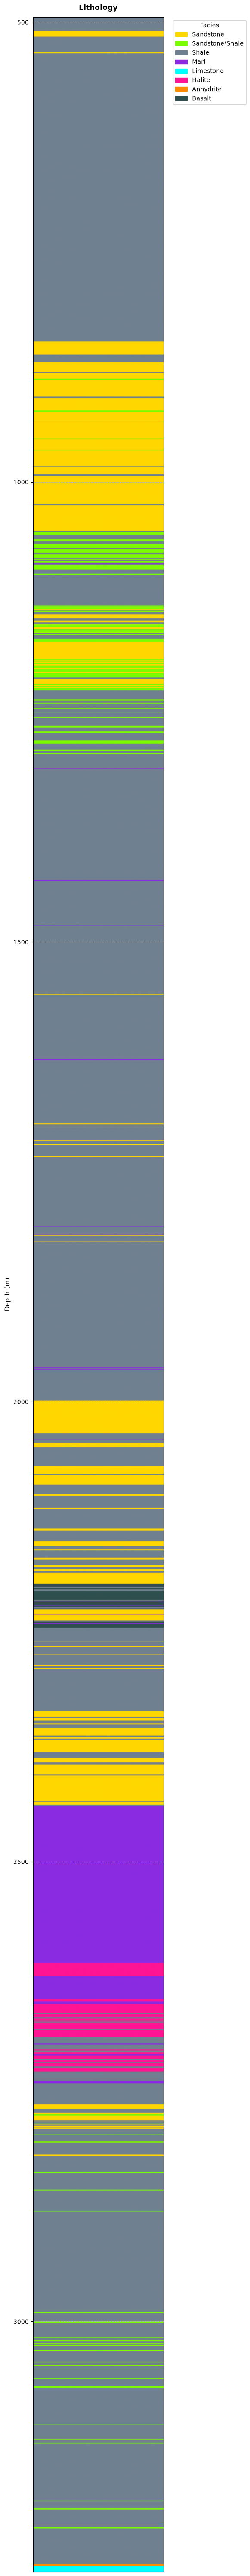

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Define FORCE 2020 lithology encoding & color palette
LITHOLOGY_MAP = {
    30000: "Sandstone",
    65030: "Sandstone/Shale",
    65000: "Shale",
    70000: "Marl",
    74000: "Limestone",
    70032: "Chalk",
    80000: "Halite",
    86000: "Anhydrite",
    88000: "Dolomite",
    90000: "Tuff",
    99000: "Basalt",
    95000: "Coal"
}

# LITHOLOGY_COLORS = {
#     30000: "#ffff00",  # Sandstone (Yellow)
#     65030: "#ffe119",  # Sand/Shale (Light Yellow/Green)
#     65000: "#bebebe",  # Shale (Grey)
#     70000: "#808000",  # Marl (Olive)
#     74000: "#800000",  # Limestone (Cyan/Light Blue or Maroon)
#     70032: "#00ffff",  # Chalk (Light Blue)
#     80000: "#7f7f7f",  # Halite
#     86000: "#008080",  # Anhydrite
#     88000: "#800080",  # Dolomite
#     90000: "#ff00ff",  # Tuff
#     99000: "#000000",  # Basalt
#     95000: "#000000",  # Coal (Black)
# }


LITHOLOGY_COLORS = {
    30000: "#FFD700",  # Sandstone -> Bright Gold/Yellow
    65030: "#7CFC00",  # Sandstone/Shale -> Lawn Green (Distinct from yellow & grey)
    65000: "#708090",  # Shale -> Slate Grey
    70000: "#8A2BE2",  # Marl -> Blue Violet (Stands out from shales & limestones)
    74000: "#00FFFF",  # Limestone -> Bright Cyan
    70032: "#1E90FF",  # Chalk -> Dodger Blue (Differentiates from Cyan Limestone)
    80000: "#FF1493",  # Halite -> Deep Pink (High contrast against salts/evaporites)
    86000: "#FF8C00",  # Anhydrite -> Dark Orange
    88000: "#800080",  # Dolomite -> Royal Purple
    90000: "#FF4500",  # Tuff -> Orange-Red
    99000: "#2F4F4F",  # Basalt -> Dark Slate/Charcoal (Replaces pure black)
    95000: "#000000",  # Coal -> Jet Black
}

# 2. Extract arrays and drop rows where depth or lithology is NaN
valid_mask = depth.notna() & lithology.notna()
sub_depth = depth[valid_mask].values
sub_litho = lithology[valid_mask].values

# 3. Create discrete colormap setup
unique_codes = list(LITHOLOGY_MAP.keys())
cmap = mcolors.ListedColormap([LITHOLOGY_COLORS.get(code, "#ffffff") for code in unique_codes])
norm = mcolors.BoundaryNorm(boundaries=np.arange(len(unique_codes) + 1) - 0.5, ncolors=len(unique_codes))

# Map lithology values to categorical integer indices (0 to N-1)
code_to_idx = {code: i for i, code in enumerate(unique_codes)}
litho_idx = np.array([code_to_idx.get(val, -1) for val in sub_litho])

# 4. Plot vertical track
fig, ax = plt.subplots(figsize=(6, 60))

# Display lithology column as 2D vertical image strip
img = ax.imshow(
    litho_idx[:, np.newaxis],
    aspect="auto",
    cmap=cmap,
    norm=norm,
    extent=[0, 1, sub_depth.max(), sub_depth.min()]  # Invert y-limits to make depth go down
)

# 5. Formatting & Layout
ax.set_title("Lithology", fontsize=12, fontweight="bold", pad=12)
ax.set_ylabel("Depth (m)", fontsize=11)
ax.set_xticks([])  # Remove X-axis numbers for clean track style
ax.grid(True, which="both", axis="y", linestyle="--", alpha=1)

# 6. Discrete Legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=LITHOLOGY_COLORS.get(code, "#ffffff"), label=name)
    for code, name in LITHOLOGY_MAP.items()
    if code in sub_litho
]
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True,
    title="Facies",
    title_fontsize="10"
)

plt.tight_layout()
plt.show()

for all well

chatgpt's way

In [66]:
from pathlib import Path
import lasio
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Dataset location
# --------------------------------------------------

DATA_DIR = Path("../data/raw/FORCE_2020")

las_files = sorted(DATA_DIR.glob("*.las"))

print(f"Number of LAS files found: {len(las_files)}")

# --------------------------------------------------
# 2. Load all wells
# --------------------------------------------------

wells = {}

for las_file in las_files:
    try:
        las = lasio.read(las_file)
        wells[las_file.stem] = las

    except Exception as e:
        print(f"ERROR reading {las_file.name}: {e}")

print(f"Successfully loaded wells: {len(wells)}")

# --------------------------------------------------
# 3. Inspect curves of first few wells
# --------------------------------------------------

for i, (well_name, las) in enumerate(wells.items()):

    print("\n" + "=" * 70)
    print(f"Well: {well_name}")
    print(f"Number of curves: {len(las.curves)}")

    print("Curves:")
    print([curve.mnemonic for curve in las.curves])

    if i >= 4:
        break

Number of LAS files found: 118
Successfully loaded wells: 118

Well: 15_9-13
Number of curves: 21
Curves:
['DEPT', 'FORCE_2020_LITHOFACIES_CONFIDENCE', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'CALI', 'MUDWEIGHT', 'ROP', 'RDEP', 'RSHA', 'RMED', 'RXO', 'SP', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB', 'DRHO', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC']

Well: 15_9-14
Number of curves: 21
Curves:
['DEPT', 'FORCE_2020_LITHOFACIES_CONFIDENCE', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'CALI', 'MUDWEIGHT', 'ROP', 'RDEP', 'RSHA', 'RMED', 'RXO', 'SP', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB', 'DRHO', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC']

Well: 15_9-15
Number of curves: 23
Curves:
['DEPT', 'FORCE_2020_LITHOFACIES_CONFIDENCE', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'CALI', 'BS', 'DCAL', 'MUDWEIGHT', 'ROP', 'RDEP', 'RSHA', 'RMED', 'RXO', 'SP', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB', 'DRHO', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC']

Well: 15_9-17
Number of curves: 22
Curves:
['DEPT', 'FORCE_2020_LITHOFACIES_CONFIDENCE', 'FORCE_2020_

In [67]:
# --------------------------------------------------
# Cell 2: Inspect lithology-labelled intervals
# --------------------------------------------------

DEPTH_CURVE = "DEPT"
LITHOLOGY_CURVE = "FORCE_2020_LITHOFACIES_LITHOLOGY"

well_summary = []

for well_name, las in wells.items():

    # Convert LAS to DataFrame
    df = las.df().reset_index()

    # Make sure depth column has the expected name
    if DEPTH_CURVE not in df.columns:
        print(f"WARNING: {well_name} has no {DEPTH_CURVE}")
        continue

    if LITHOLOGY_CURVE not in df.columns:
        print(f"WARNING: {well_name} has no lithology curve")
        continue

    # Keep only depth + lithology
    temp = df[[DEPTH_CURVE, LITHOLOGY_CURVE]].copy()

    # Remove invalid depth values
    temp = temp.dropna(subset=[DEPTH_CURVE])

    # A labelled sample means lithology is present
    labelled = temp[temp[LITHOLOGY_CURVE].notna()].copy()

    # Remove common missing-value representations
    labelled = labelled[
        ~labelled[LITHOLOGY_CURVE].isin([-999, -999.25, -9999, -9999.0])
    ]

    # Information about this well
    if len(labelled) > 0:

        well_summary.append({
            "well": well_name,
            "total_samples": len(temp),
            "labelled_samples": len(labelled),
            "percent_labelled": len(labelled) / len(temp) * 100,

            "labelled_start_depth": labelled[DEPTH_CURVE].min(),
            "labelled_end_depth": labelled[DEPTH_CURVE].max(),
            "depth_step_median": temp[DEPTH_CURVE].diff().median(),
            "unique_lithologies": labelled[LITHOLOGY_CURVE].nunique()
        })

    else:

        well_summary.append({
            "well": well_name,
            "total_samples": len(temp),
            "labelled_samples": 0,
            "percent_labelled": 0.0,
            "labelled_start_depth": np.nan,
            "labelled_end_depth": np.nan,
            "depth_step_median": temp[DEPTH_CURVE].diff().median(),
            "unique_lithologies": 0

        })


# Convert summary to DataFrame
well_summary_df = pd.DataFrame(well_summary)

# Sort by well name
well_summary_df = well_summary_df.sort_values("well").reset_index(drop=True)

# Display
pd.set_option("display.max_rows", 120)

display(well_summary_df)





,well,total_samples,labelled_samples,percent_labelled,labelled_start_depth,labelled_end_depth,depth_step_median,unique_lithologies
0,15_9-13,21441,18270,85.210578,494.528000,3272.024000,0.152,8
1,15_9-14,22875,20336,88.900546,480.628001,3572.916001,0.152,8
2,15_9-15,20954,17717,84.551876,485.256000,3200.128000,0.152,7
3,15_9-17,19879,17351,87.283063,472.429998,3114.645998,0.152,7
4,15_9-23,20494,11063,53.981653,1518.280000,3212.624000,0.152,8
5,16_1-2,18547,1734,9.349221,2645.580001,2908.996002,0.152,5
6,16_1-6 A,13513,3623,26.811219,1175.979735,1726.523735,0.152,4
7,16_10-1,20147,17675,87.730183,439.415790,3125.863790,0.152,10
8,16_10-2,20131,2437,12.105708,2767.265202,3137.537202,0.152,6
9,16_10-3,17995,15956,88.669075,415.261599,2840.421599,0.152,8


In [ ]:
output_folder = "./visualization_result"
output_file = "overall wells feature and label distribution.csv"

os.makedirs(output_folder, exist_ok=True)

full_path = os.path.join(output_folder, output_file)

well_summary_df.to_csv(full_path, index=False)

print(f"Saved successfully to: {full_path}")

In [77]:
print(
 "sum of all the samples in all wells: ", well_summary_df["total_samples"].sum(),
 "sum of all the labelled samples in all wells: ", well_summary_df["labelled_samples"].sum(),
 "percent of labelled samples in all wells: ", well_summary_df["labelled_samples"].sum() / well_summary_df["total_samples"].sum() * 100
)

sum of all the samples in all wells:  2337639 sum of all the labelled samples in all wells:  1431383 percent of labelled samples in all wells:  61.23199518830752


In [68]:
print("Total wells:", len(well_summary_df))
print(
    "Wells containing lithology labels:",
    (well_summary_df["labelled_samples"] > 0).sum()
)
print(
    "Wells without lithology labels:",
    (well_summary_df["labelled_samples"] == 0).sum()
)

print("\nTotal labelled samples:")
print(well_summary_df["labelled_samples"].sum())

Total wells: 118
Wells containing lithology labels: 118
Wells without lithology labels: 0

Total labelled samples:
1431383


In [78]:
# --------------------------------------------------
# Cell 3: Determine universal depth range
# --------------------------------------------------

DEPTH_STEP = 0.152  # observed sampling interval in the dataset

# Minimum and maximum labelled depths across ALL wells
global_min_depth = well_summary_df["labelled_start_depth"].min()
global_max_depth = well_summary_df["labelled_end_depth"].max()

print(f"Global minimum labelled depth : {global_min_depth:.6f} m")
print(f"Global maximum labelled depth : {global_max_depth:.6f} m")
print(f"Depth sampling interval       : {DEPTH_STEP:.3f} m")

# Number of samples required for the universal grid
n_universal = int(
    np.floor((global_max_depth - global_min_depth) / DEPTH_STEP)
) + 1

print(f"Universal depth samples       : {n_universal:,}")

# Create universal depth axis
universal_depth = (
    global_min_depth +
    np.arange(n_universal) * DEPTH_STEP
)

print("\nFirst 10 universal depths:")
print(universal_depth[:10])

print("\nLast 10 universal depths:")
print(universal_depth[-10:])

Global minimum labelled depth : 80.150000 m
Global maximum labelled depth : 5436.632000 m
Depth sampling interval       : 0.152 m
Universal depth samples       : 35,241

First 10 universal depths:
[80.15  80.302 80.454 80.606 80.758 80.91  81.062 81.214 81.366 81.518]

Last 10 universal depths:
[5435.262 5435.414 5435.566 5435.718 5435.87  5436.022 5436.174 5436.326
 5436.478 5436.63 ]


In [79]:
# --------------------------------------------------
# Cell 5: Build universal depth from ACTUAL labelled depths
# --------------------------------------------------

all_labelled_depths = []

for well_name, las in wells.items():

    df = las.df().reset_index()

    # Keep only depth + lithology
    temp = df[[DEPTH_CURVE, LITHOLOGY_CURVE]].copy()

    # Keep only rows where both depth and lithology exist
    labelled = temp.dropna(
        subset=[DEPTH_CURVE, LITHOLOGY_CURVE]
    ).copy()

    # Remove known missing-value codes
    labelled = labelled[
        ~labelled[LITHOLOGY_CURVE].isin(
            [-999, -999.25, -9999, -9999.0]
        )
    ]

    # Store actual labelled depths
    all_labelled_depths.extend(
        labelled[DEPTH_CURVE].to_numpy()
    )


# Convert to NumPy array
all_labelled_depths = np.asarray(all_labelled_depths)


# --------------------------------------------------
# Create universal depth column
# --------------------------------------------------

universal_depth_actual = np.unique(
    np.round(all_labelled_depths, 6)
)

universal_depth_actual.sort()


# --------------------------------------------------
# Report
# --------------------------------------------------

print(f"Total labelled depth samples collected : {len(all_labelled_depths):,}")
print(f"Unique universal depths                : {len(universal_depth_actual):,}")

print("\nUniversal depth range:")
print(f"Minimum: {universal_depth_actual.min():.6f} m")
print(f"Maximum: {universal_depth_actual.max():.6f} m")

print("\nFirst 20 universal depths:")
print(universal_depth_actual[:20])

print("\nLast 20 universal depths:")
print(universal_depth_actual[-20:])

Total labelled depth samples collected : 1,431,383
Unique universal depths                : 1,388,921

Universal depth range:
Minimum: 80.150000 m
Maximum: 5436.632000 m

First 20 universal depths:
[80.15  80.302 80.454 80.606 80.758 80.91  81.062 81.214 81.366 81.518
 81.67  81.822 81.974 82.126 82.278 82.43  82.582 82.734 82.886 83.038]

Last 20 universal depths:
[5433.744 5433.896 5434.048 5434.2   5434.352 5434.504 5434.656 5434.808
 5434.96  5435.112 5435.264 5435.416 5435.568 5435.72  5435.872 5436.024
 5436.176 5436.328 5436.48  5436.632]


In [ ]:
# --------------------------------------------------
# Cell 6: Check alignment using ONLY labelled samples
# --------------------------------------------------

labelled_alignment_summary = []

for well_name, las in wells.items():

    df = las.df().reset_index()

    temp = df[[DEPTH_CURVE, LITHOLOGY_CURVE]].copy()

    # ONLY labelled samples
    labelled = temp.dropna(
        subset=[DEPTH_CURVE, LITHOLOGY_CURVE]
    ).copy()

    labelled = labelled[
        ~labelled[LITHOLOGY_CURVE].isin(
            [-999, -999.25, -9999, -9999.0]
        )
    ]

    depths = labelled[DEPTH_CURVE].to_numpy()

    if len(depths) == 0:
        continue

    # Find nearest universal grid point
    indices = np.searchsorted(
        universal_depth,
        depths
    )

    # Handle boundaries
    indices = np.clip(
        indices,
        1,
        len(universal_depth) - 1
    )

    left = universal_depth[indices - 1]
    right = universal_depth[indices]

    choose_right = (
        np.abs(right - depths) <
        np.abs(depths - left)
    )

    nearest_indices = np.where(
        choose_right,
        indices,
        indices - 1
    )

    nearest_depths = universal_depth[nearest_indices]

    errors = np.abs(
        depths - nearest_depths
    )

    # Check whether multiple labelled samples
    # from THIS well map to the same grid depth
    unique_indices = np.unique(nearest_indices)

    collisions = (
        len(nearest_indices) -
        len(unique_indices)
    )

    labelled_alignment_summary.append({
        "well": well_name,
        "labelled_samples": len(depths),
        "max_error_m": errors.max(),
        "mean_error_m": errors.mean(),
        "median_error_m": np.median(errors),
        "95_percent_error_m": np.percentile(errors, 95),
        "collisions": collisions
    })


labelled_alignment_df = pd.DataFrame(
    labelled_alignment_summary
)

display(labelled_alignment_df)

print("\nOverall:")
print(
    "Maximum error:",
    labelled_alignment_df["max_error_m"].max(),
    "m"
)

print(
    "Mean error:",
    labelled_alignment_df["mean_error_m"].mean(),
    "m"
)

print(
    "95th percentile error:",
    labelled_alignment_df["95_percent_error_m"].max(),
    "m"
)

print(
    "Wells with collisions:",
    (
        labelled_alignment_df["collisions"] > 0
    ).sum()
)

In [80]:
# --------------------------------------------------
# Cell 7: Build universal-depth lithology matrix
# --------------------------------------------------

# Use the regular 0.152 m universal grid
DEPTH_STEP = 0.152

# Re-create the universal grid cleanly
n_universal = int(
    np.floor(
        (global_max_depth - global_min_depth) / DEPTH_STEP
    )
) + 1

universal_depth = (
    global_min_depth
    + np.arange(n_universal) * DEPTH_STEP
)

# Round only for clean representation
universal_depth = np.round(universal_depth, 3)

print(f"Universal depth rows: {len(universal_depth):,}")
print(
    f"Depth range: "
    f"{universal_depth[0]:.3f} → "
    f"{universal_depth[-1]:.3f} m"
)


# --------------------------------------------------
# Create empty matrix
# --------------------------------------------------

lithology_matrix = pd.DataFrame(
    index=np.arange(len(universal_depth))
)

# First column = universal depth
lithology_matrix["Depth"] = universal_depth


# --------------------------------------------------
# Process every well
# --------------------------------------------------

for well_name, las in wells.items():

    df = las.df().reset_index()

    # Select only required columns
    temp = df[
        [DEPTH_CURVE, LITHOLOGY_CURVE]
    ].copy()

    # --------------------------------------------------
    # Keep ONLY rows where lithology is present
    # --------------------------------------------------

    temp = temp.dropna(
        subset=[
            DEPTH_CURVE,
            LITHOLOGY_CURVE
        ]
    )

    # Remove known missing-value codes
    temp = temp[
        ~temp[LITHOLOGY_CURVE].isin(
            [-999, -999.25, -9999, -9999.0]
        )
    ]

    if len(temp) == 0:
        continue

    # --------------------------------------------------
    # Map actual depth → universal grid index
    # --------------------------------------------------

    grid_indices = np.rint(
        (
            temp[DEPTH_CURVE].to_numpy()
            - global_min_depth
        ) / DEPTH_STEP
    ).astype(int)

    # Keep only valid universal-grid positions
    valid = (
        (grid_indices >= 0)
        & (grid_indices < len(universal_depth))
    )

    grid_indices = grid_indices[valid]

    lithologies = (
        temp[LITHOLOGY_CURVE]
        .to_numpy()[valid]
    )

    # --------------------------------------------------
    # Create this well's column
    # --------------------------------------------------

    well_column = np.full(
        len(universal_depth),
        np.nan
    )

    well_column[grid_indices] = lithologies

    # Add to matrix
    lithology_matrix[well_name] = well_column


# --------------------------------------------------
# Final structure
# --------------------------------------------------

print(
    f"\nRows: {lithology_matrix.shape[0]:,}"
)

print(
    f"Columns: {lithology_matrix.shape[1]:,}"
)

print(
    f"Wells: {lithology_matrix.shape[1] - 1:,}"
)

display(lithology_matrix.head(20))

Universal depth rows: 35,241
Depth range: 80.150 → 5436.630 m

Rows: 35,241
Columns: 119
Wells: 118


/var/folders/81/rxfkyzcs2vj936htlz87zzc00000gn/T/ipykernel_92929/3453216044.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lithology_matrix[well_name] = well_column
/var/folders/81/rxfkyzcs2vj936htlz87zzc00000gn/T/ipykernel_92929/3453216044.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lithology_matrix[well_name] = well_column
/var/folders/81/rxfkyzcs2vj936htlz87zzc00000gn/T/ipykernel_92929/3453216044.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` 

,Depth,15_9-13,15_9-14,15_9-15,15_9-17,15_9-23,16_1-2,16_1-6 A,16_10-1,16_10-2,...,35_8-6 S,35_9-10 S,35_9-2,35_9-5,35_9-6 S,35_9-7,35_9-8,36_7-3,7_1-1,7_1-2 S
0,80.150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,80.302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,80.454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,80.606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,80.758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,80.910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,81.062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,81.214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,81.366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,81.518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(lithology_matrix.shape)

print("\nNon-null lithology values:")
print(
    lithology_matrix.iloc[:, 1:].notna().sum().sum()
)

print("\nExpected labelled samples:")
print(
    well_summary_df["labelled_samples"].sum()
)

In [ ]:
# --------------------------------------------------
# Cell 8: Verify every well
# --------------------------------------------------

verification = []

for well_name in wells.keys():

    # Number of labels originally present
    original_count = well_summary_df.loc[
        well_summary_df["well"] == well_name,
        "labelled_samples"
    ].iloc[0]

    # Number of labels now present in matrix
    matrix_count = lithology_matrix[well_name].notna().sum()

    verification.append({
        "well": well_name,
        "original_labelled_samples": original_count,
        "matrix_labelled_samples": matrix_count,
        "difference": matrix_count - original_count,
        "status": "OK" if matrix_count == original_count else "ERROR"
    })


verification_df = pd.DataFrame(verification)

display(verification_df)

print("\nVerification summary:")
print(
    "Wells verified:",
    len(verification_df)
)

print(
    "Wells with errors:",
    (verification_df["status"] != "OK").sum()
)

print(
    "Total original labels:",
    verification_df["original_labelled_samples"].sum()
)

print(
    "Total matrix labels:",
    verification_df["matrix_labelled_samples"].sum()
)

In [ ]:
# --------------------------------------------------
# Cell 9: Save final universal-depth lithology matrix
# --------------------------------------------------

OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_file = OUTPUT_DIR / "universal_depth_lithology.csv"

lithology_matrix.to_csv(
    output_file,
    index=False
)

print(f"Saved successfully:")
print(output_file)

print(
    f"\nFile shape: "
    f"{lithology_matrix.shape[0]:,} rows × "
    f"{lithology_matrix.shape[1]:,} columns"
)

print(
    f"File size: "
    f"{output_file.stat().st_size / (1024**2):.2f} MB"
)

**function to plot the wells and their combinatiopn**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch


# --------------------------------------------------
# FORCE 2020 lithology mapping
# --------------------------------------------------

LITHOLOGY_MAP = {
    30000: "Sandstone",
    65030: "Sandstone/Shale",
    65000: "Shale",
    80000: "Marl",
    74000: "Dolomite",
    70000: "Limestone",
    70032: "Chalk",
    88000: "Halite",
    86000: "Anhydrite",
    99000: "Tuff",
    90000: "Coal",
    93000: "Basement",
}


# --------------------------------------------------
# Colors
# --------------------------------------------------

LITHOLOGY_COLORS = {
    30000: "#FFD700",   # Sandstone
    65030: "#7CFC00",   # Sandstone/Shale
    65000: "#708090",   # Shale
    80000: "#8A2BE2",   # Marl
    74000: "#00FFFF",   # Dolomite
    70000: "#1E90FF",   # Limestone
    70032: "#1E90FF",   # Chalk
    88000: "#FF1493",   # Halite
    86000: "#FF8C00",   # Anhydrite
    99000: "#FF4500",   # Tuff
    90000: "#000000",   # Coal
    93000: "#2F4F4F",   # Basement
}


# --------------------------------------------------
# Plot function
# --------------------------------------------------

def plot_lithology_wells(
    well_names,
    depth_min=None,
    depth_max=None,
    figsize=None
):

    # -----------------------------
    # Check requested wells
    # -----------------------------

    missing_wells = [
        well for well in well_names
        if well not in lithology_matrix.columns
    ]

    if missing_wells:
        raise ValueError(
            f"These wells were not found: {missing_wells}"
        )

    if len(well_names) == 0:
        raise ValueError("No wells were selected.")

    # -----------------------------
    # Universal depth
    # -----------------------------

    depth = lithology_matrix["Depth"].to_numpy()

    # Depth selection
    mask = np.ones(len(depth), dtype=bool)

    if depth_min is not None:
        mask &= depth >= depth_min

    if depth_max is not None:
        mask &= depth <= depth_max

    depth_sub = depth[mask]

    # -----------------------------
    # Lithology matrix
    # -----------------------------

    litho = lithology_matrix.loc[
        mask,
        well_names
    ].to_numpy()

    # -----------------------------
    # Convert lithology codes
    # into categorical indices
    # -----------------------------

    codes = list(LITHOLOGY_MAP.keys())

    code_to_index = {
        code: i
        for i, code in enumerate(codes)
    }

    litho_index = np.full(
        litho.shape,
        np.nan
    )

    for code, index in code_to_index.items():

        litho_index[litho == code] = index

    # -----------------------------
    # Colormap
    # -----------------------------

    colors = [
        LITHOLOGY_COLORS.get(code, "#FFFFFF")
        for code in codes
    ]

    cmap = mcolors.ListedColormap(colors)

    # Make NaN transparent
    cmap.set_bad(alpha=0)

    norm = mcolors.BoundaryNorm(
        np.arange(len(codes) + 1) - 0.5,
        len(codes)
    )

    # -----------------------------
    # Figure size
    # -----------------------------

    n_wells = len(well_names)

    if figsize is None:
        figsize = (
            max(3, n_wells * 1.1),
            15
        )

    fig, ax = plt.subplots(
        figsize=figsize
    )

    # -----------------------------
    # Plot
    # -----------------------------

    # Since universal depth spacing is uniform,
    # imshow is appropriate here.

    ax.imshow(
        litho_index,
        aspect="auto",
        cmap=cmap,
        norm=norm,
        extent=[
            -0.5,
            n_wells - 0.5,
            depth_sub.max(),
            depth_sub.min()
        ],
        interpolation="none"
    )

    # -----------------------------
    # X axis
    # -----------------------------

    ax.set_xticks(
        np.arange(n_wells)
    )

    ax.set_xticklabels(
        well_names,
        rotation=45,
        ha="right"
    )

    ax.set_xlabel("Well")

    # -----------------------------
    # Y axis
    # -----------------------------

    ax.set_ylabel("Depth (m)")

    # -----------------------------
    # Grid
    # -----------------------------

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    # -----------------------------
    # Title
    # -----------------------------

    ax.set_title(
        "Lithology Comparison",
        fontsize=13,
        fontweight="bold"
    )

    # -----------------------------
    # Legend
    # -----------------------------

    present_codes = set(
        litho[~np.isnan(litho)]
        .astype(int)
        .flatten()
    )

    handles = [
        Patch(
            facecolor=LITHOLOGY_COLORS[code],
            label=LITHOLOGY_MAP[code]
        )
        for code in codes
        if code in present_codes
    ]

    ax.legend(
        handles=handles,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Facies"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
plot_lithology_wells([
    "15_9-13",
    "15_9-14",
    "15_9-15",
    "15_9-17",
    "15_9-23"
])

In [ ]:
# --------------------------------------------------
# Cell 11: Plot all wells in groups of 20
# --------------------------------------------------

# Get all 118 well names in the same order as the matrix
all_wells = [
    col for col in lithology_matrix.columns
    if col != "Depth"
]

# Group size
GROUP_SIZE = 20

# Create groups
well_groups = [
    all_wells[i:i + GROUP_SIZE]
    for i in range(0, len(all_wells), GROUP_SIZE)
]

print(f"Total wells : {len(all_wells)}")
print(f"Total groups: {len(well_groups)}")

for i, group in enumerate(well_groups, start=1):

    print(
        f"\nGroup {i} "
        f"({len(group)} wells):"
    )

    print(group)


Plotting Group 1: 20 wells


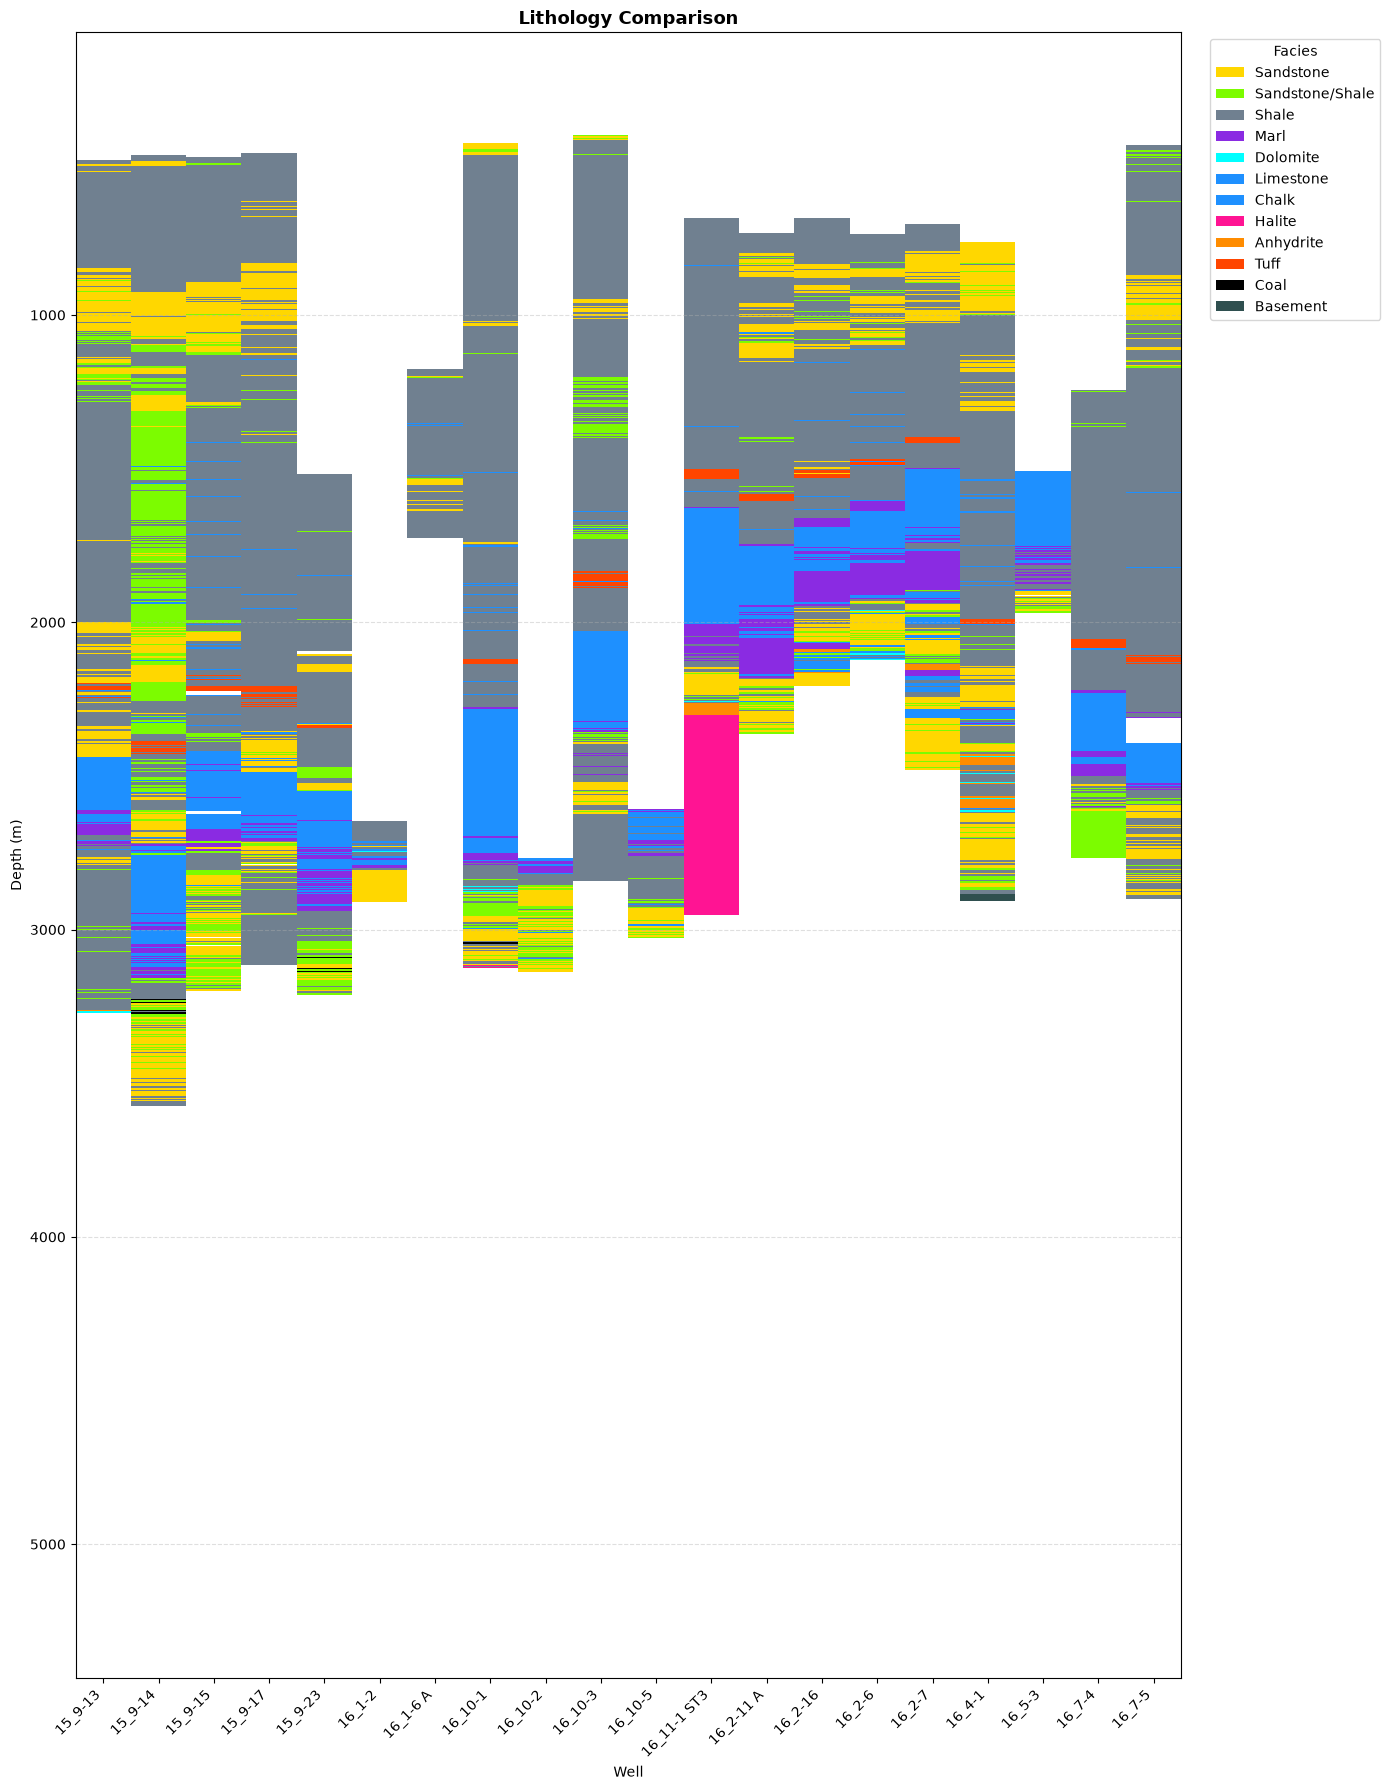


Plotting Group 2: 20 wells


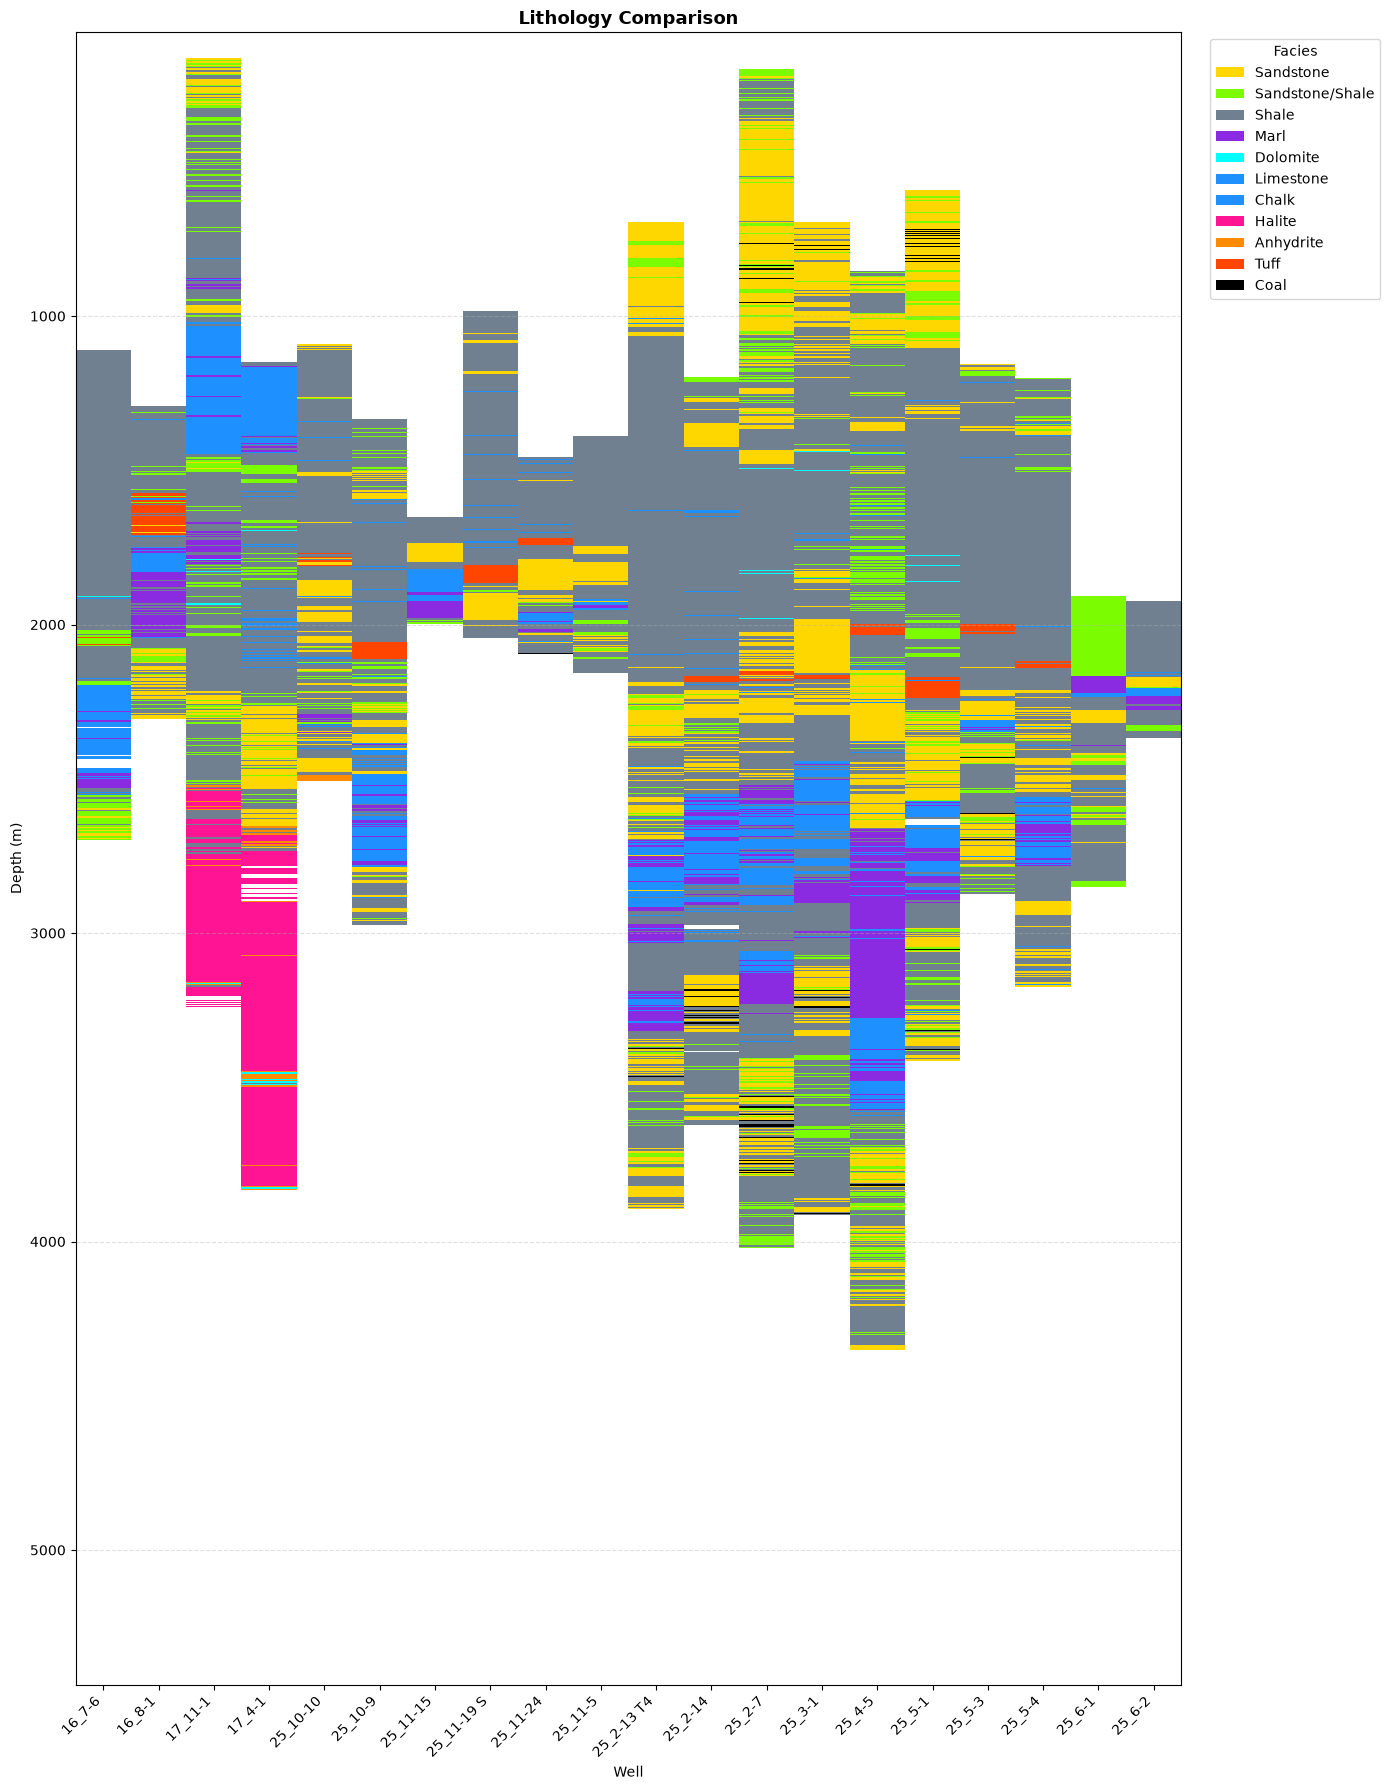


Plotting Group 3: 20 wells


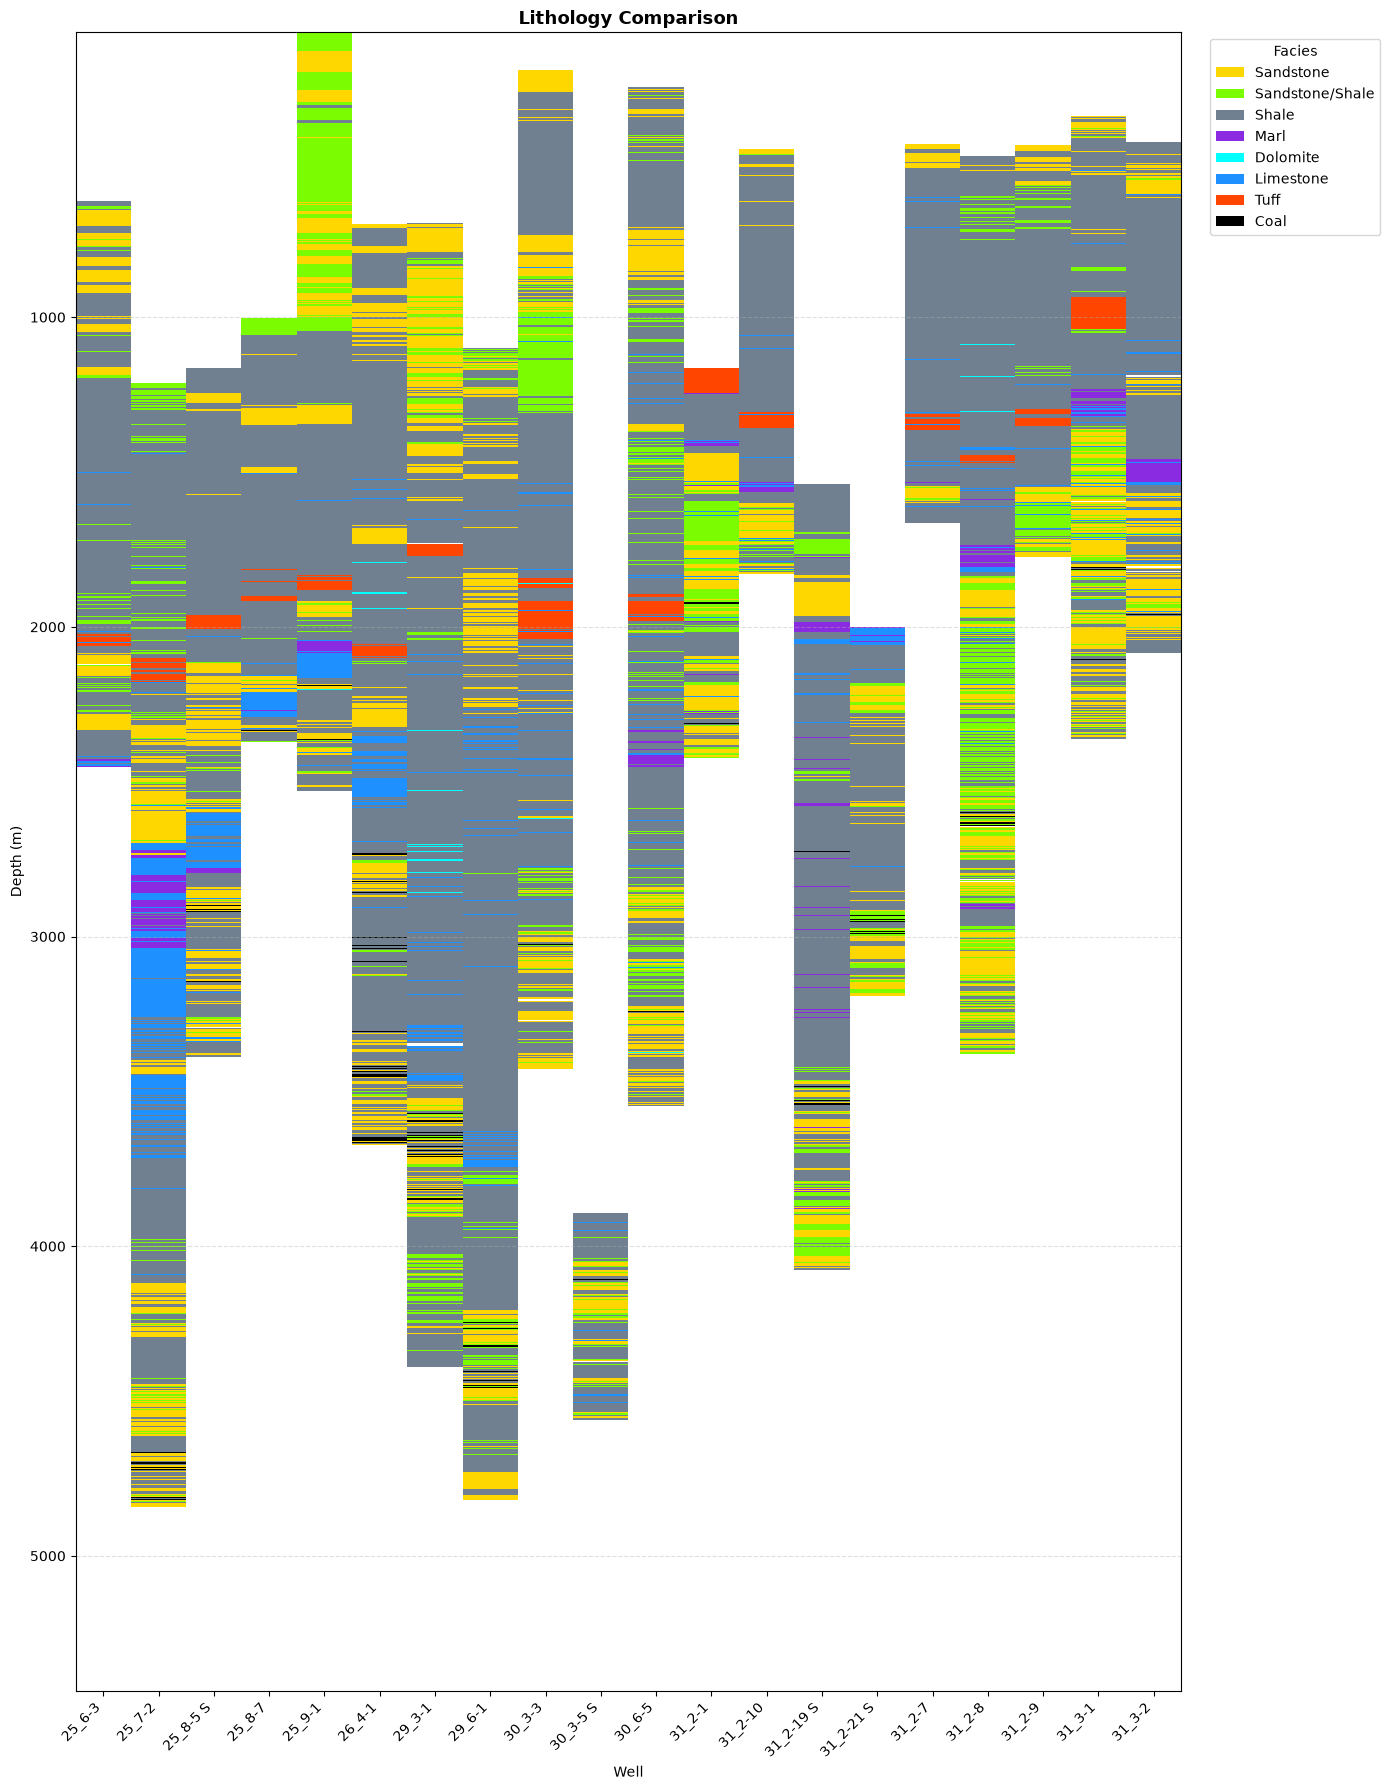


Plotting Group 4: 20 wells


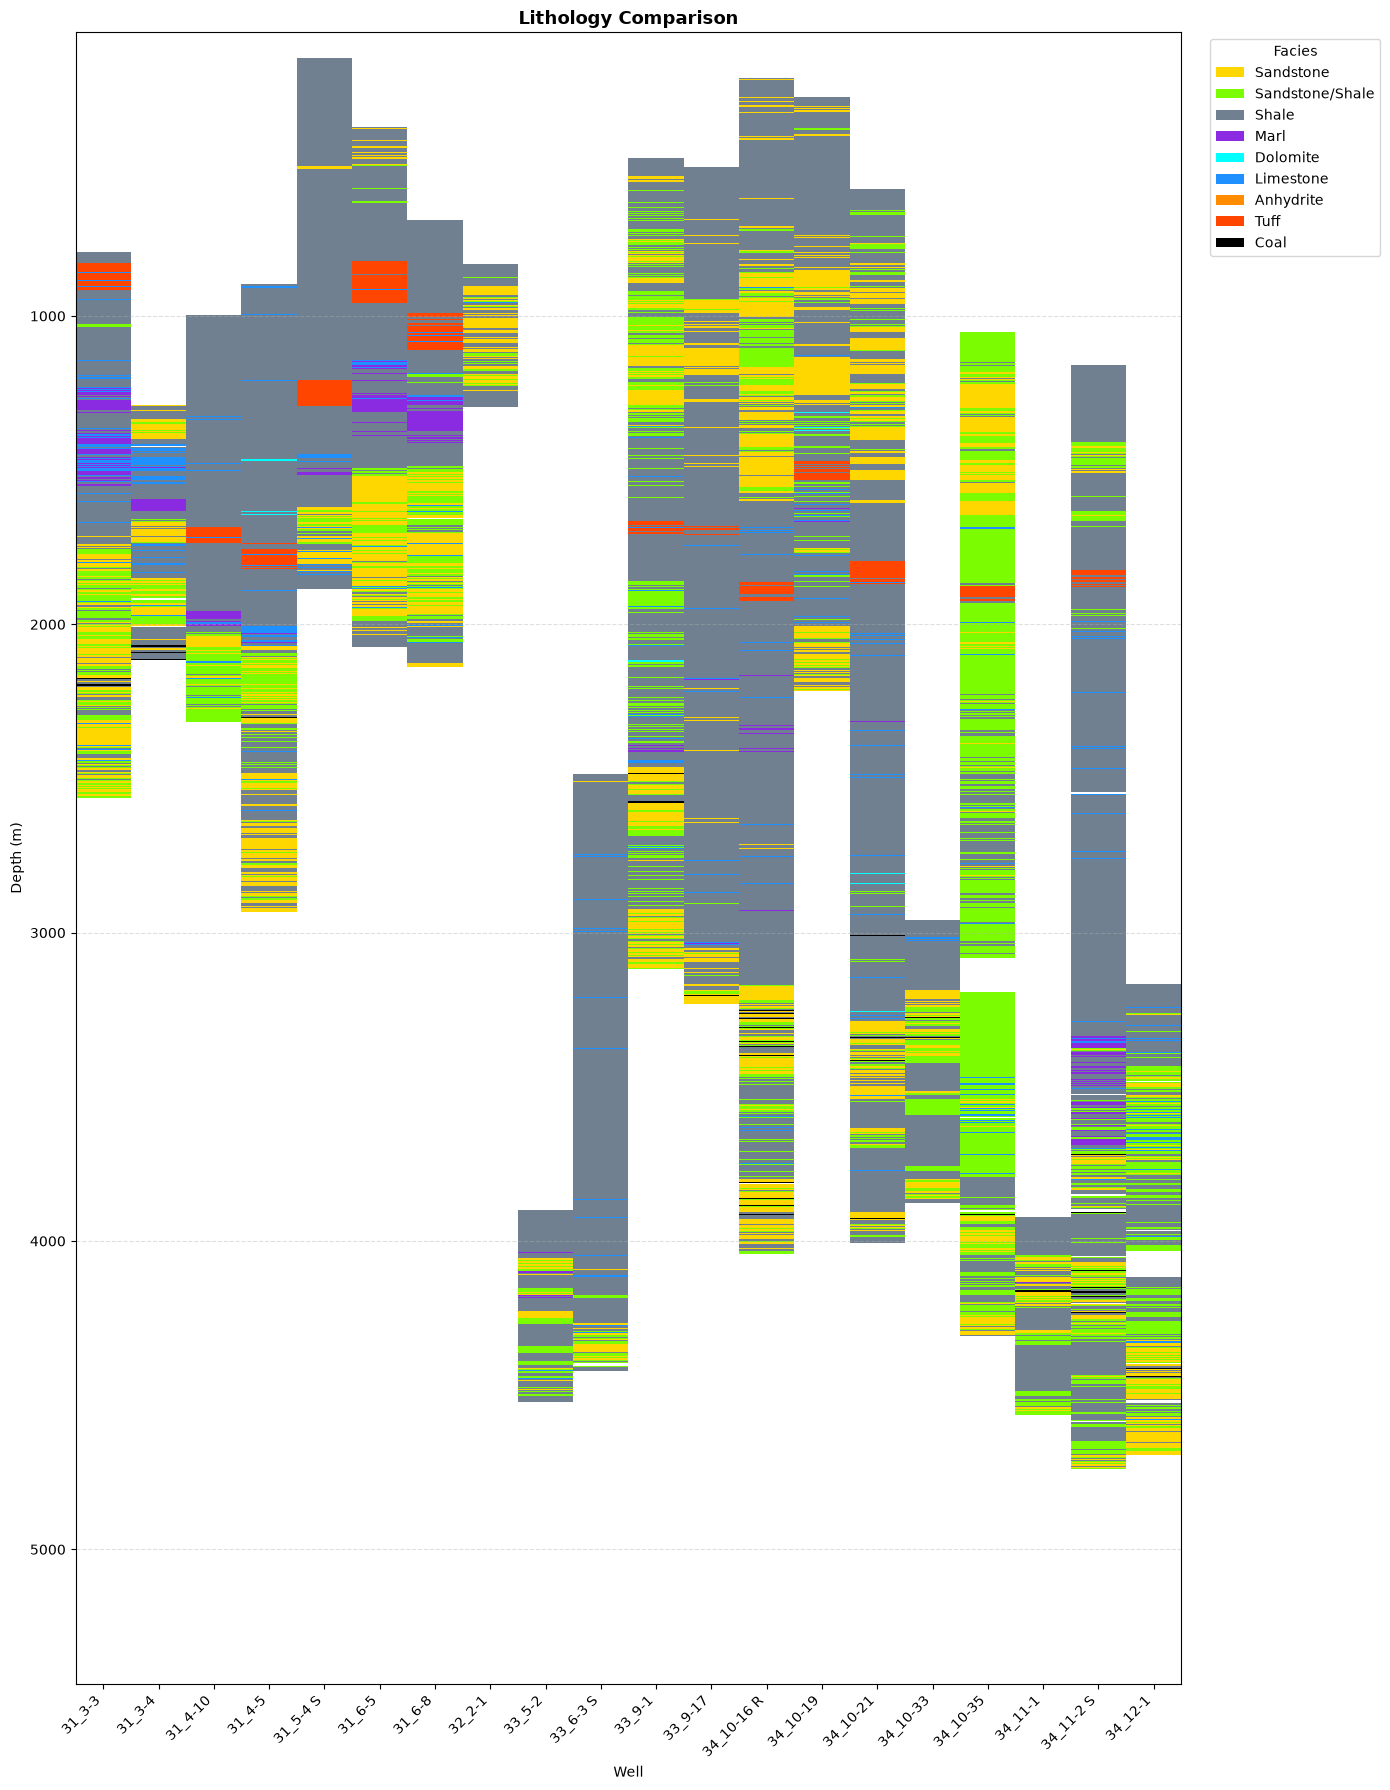


Plotting Group 5: 20 wells


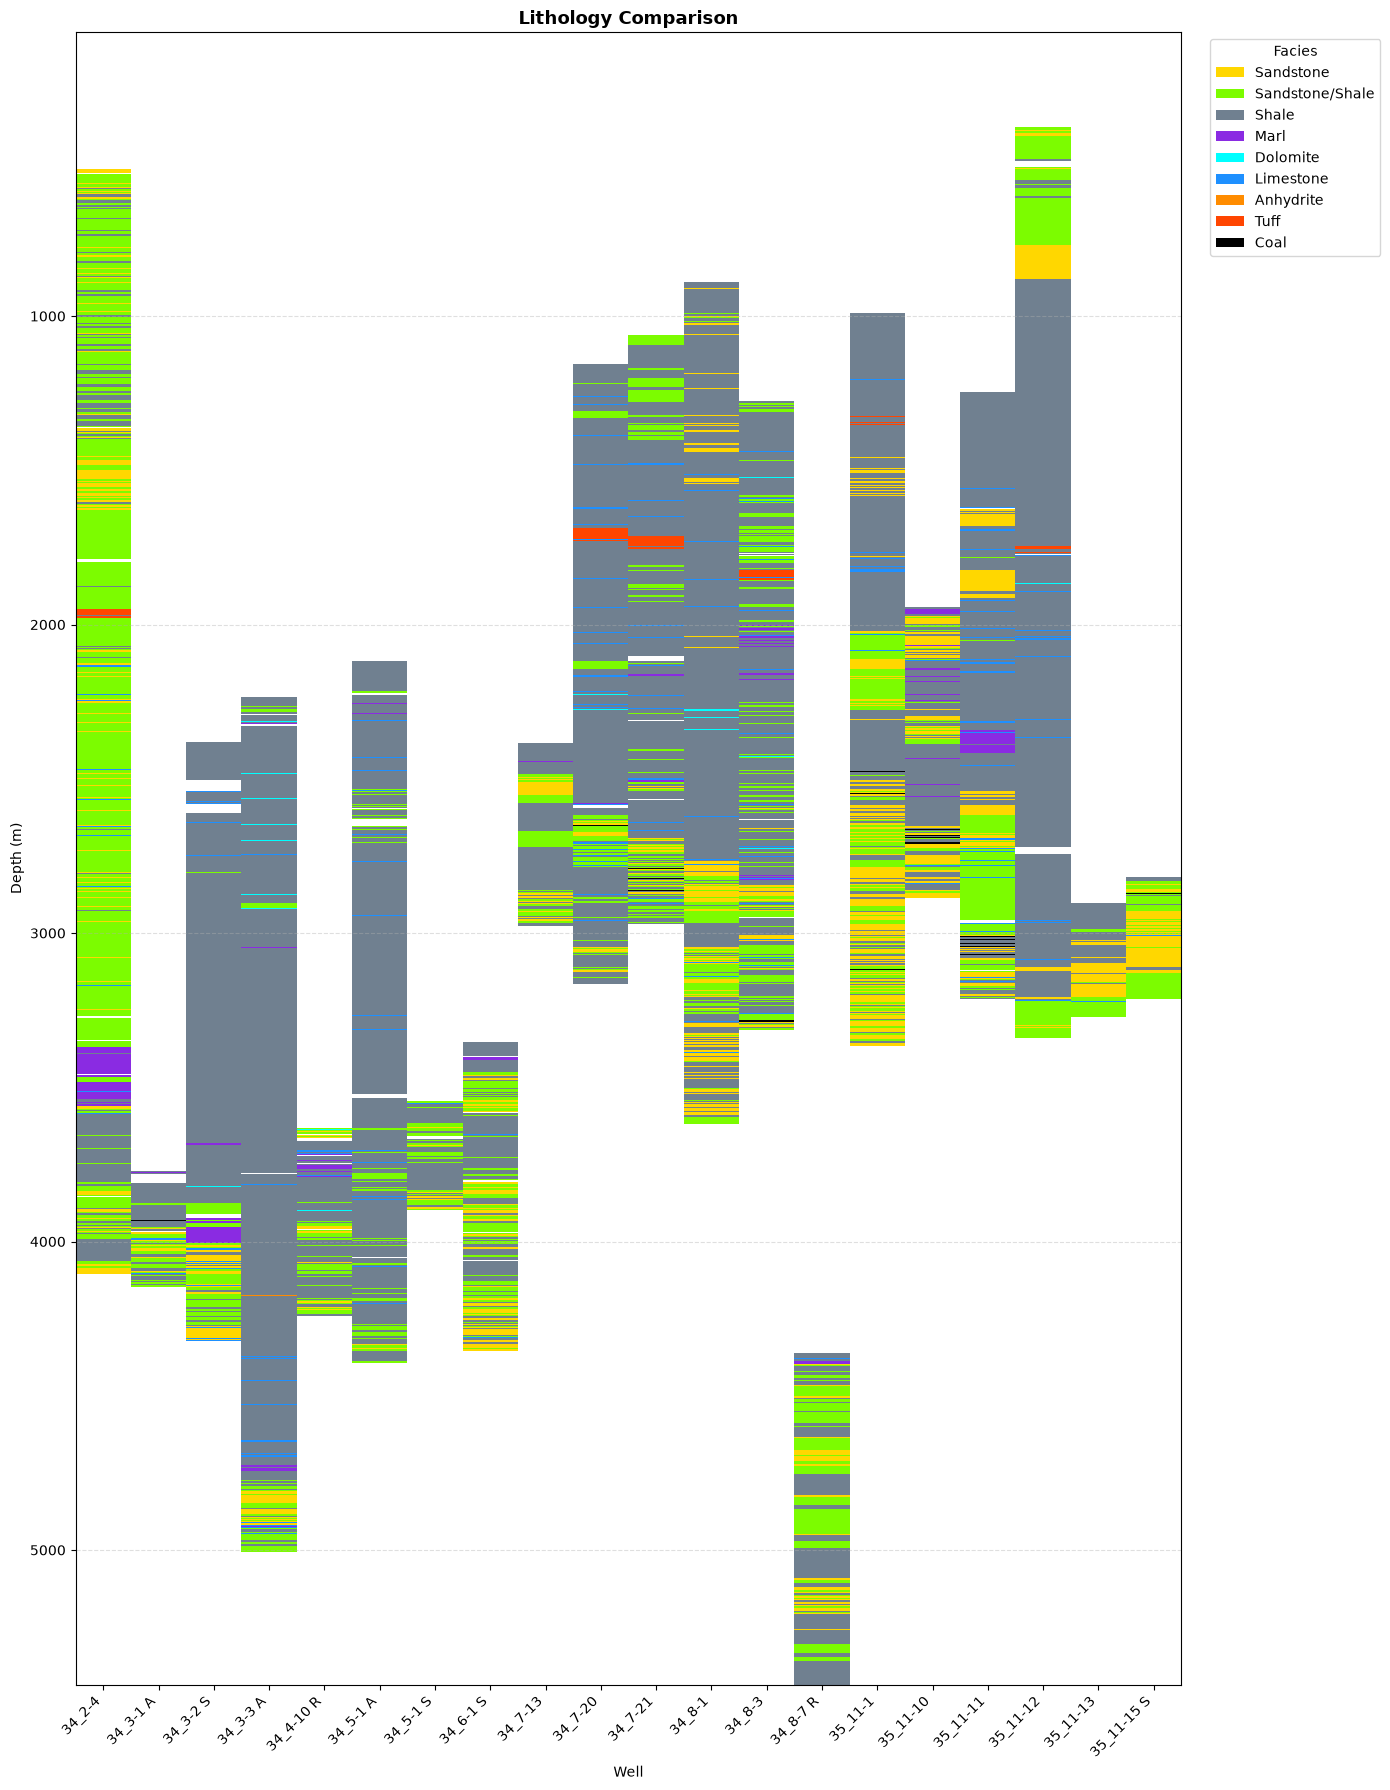


Plotting Group 6: 18 wells


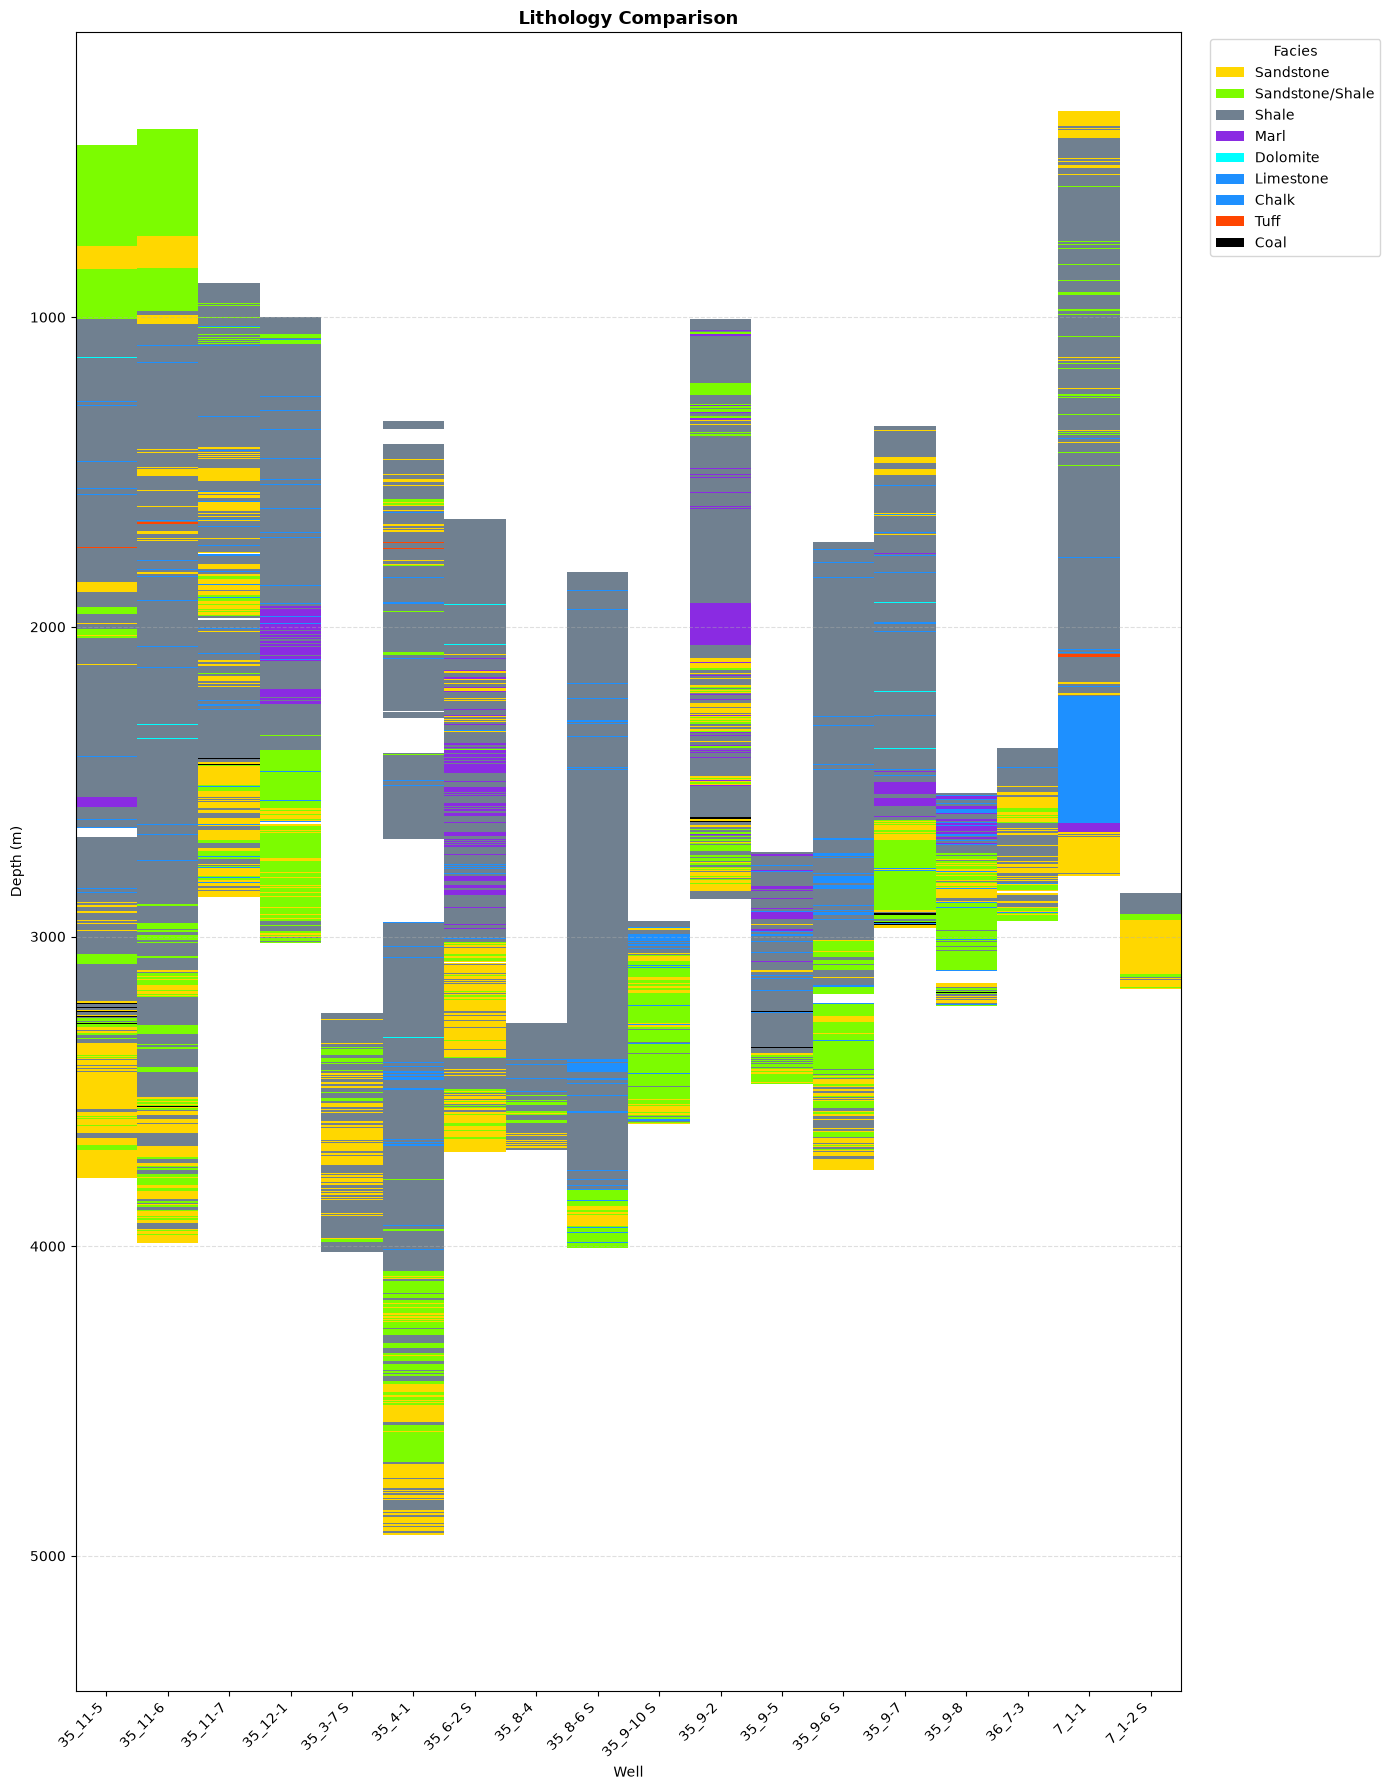

In [65]:
# --------------------------------------------------
# Plot every group of 20 wells
# --------------------------------------------------

for i, group in enumerate(well_groups, start=1):

    print(
        f"\nPlotting Group {i}: "
        f"{len(group)} wells"
    )

    plot_lithology_wells(
        group,
        figsize=(14, 18)
    )